In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("E:\CSV files\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [12]:
df.shape

(768, 9)

In [15]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:
(df==0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

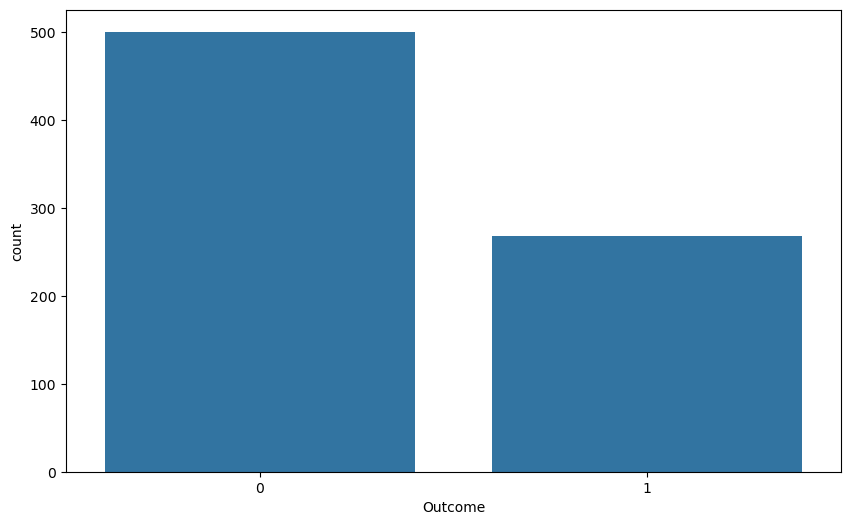

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Outcome')
plt.show()

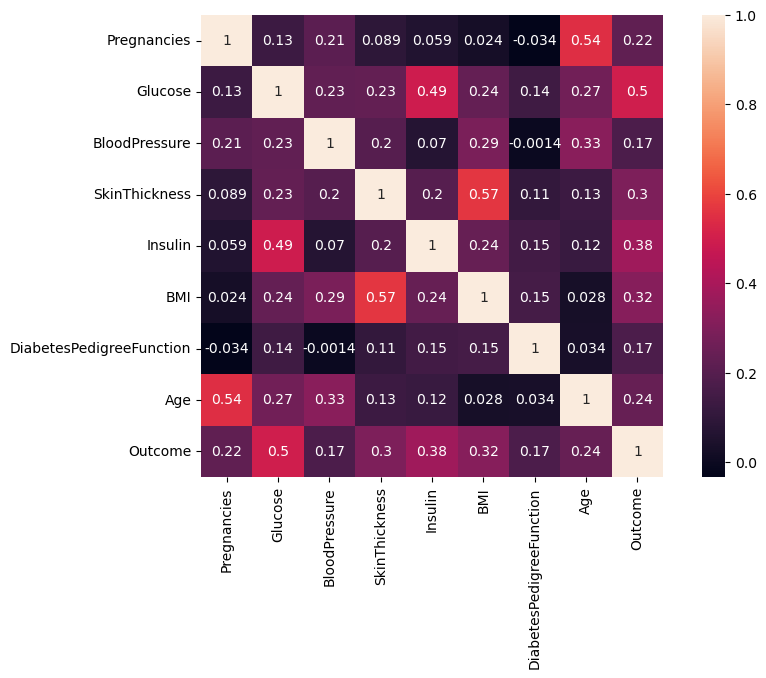

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,square=True)
plt.show()

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [23]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [24]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72.0,35,169.5,33.6,0.627,50
1,1,85,66.0,29,102.5,26.6,0.351,31
2,8,183,64.0,32,169.5,23.3,0.672,32
3,1,89,66.0,23,94.0,28.1,0.167,21
4,0,137,40.0,35,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63
764,2,122,70.0,27,102.5,36.8,0.340,27
765,5,121,72.0,23,112.0,26.2,0.245,30
766,1,126,60.0,32,169.5,30.1,0.349,47


In [25]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [26]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=14
)

In [27]:
X_train.shape

(614, 8)

In [28]:
X_test.shape

(154, 8)

In [31]:
print("Learning Target size",y_train.shape)
print("Testing Actual Target size",y_test.shape)

Learning Target size (614,)
Testing Actual Target size (154,)


In [48]:
pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("model",LogisticRegression())
])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
y_pred

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0])

In [49]:
y_prob=pipe.predict_proba(X_test)
y_prob

array([[0.57490966, 0.42509034],
       [0.95666603, 0.04333397],
       [0.29280582, 0.70719418],
       [0.40914299, 0.59085701],
       [0.95141885, 0.04858115],
       [0.89653528, 0.10346472],
       [0.74829055, 0.25170945],
       [0.98938495, 0.01061505],
       [0.95983607, 0.04016393],
       [0.86728029, 0.13271971],
       [0.954186  , 0.045814  ],
       [0.28213082, 0.71786918],
       [0.85349279, 0.14650721],
       [0.93342059, 0.06657941],
       [0.59900728, 0.40099272],
       [0.6366798 , 0.3633202 ],
       [0.90649475, 0.09350525],
       [0.04839241, 0.95160759],
       [0.35070138, 0.64929862],
       [0.51142929, 0.48857071],
       [0.66033222, 0.33966778],
       [0.96227684, 0.03772316],
       [0.89087119, 0.10912881],
       [0.98120054, 0.01879946],
       [0.47210742, 0.52789258],
       [0.9579925 , 0.0420075 ],
       [0.54895313, 0.45104687],
       [0.72118736, 0.27881264],
       [0.95448595, 0.04551405],
       [0.84123913, 0.15876087],
       [0.

In [50]:
df.loc[15,:].values

array([  7.   , 100.   ,  74.5  ,  32.   , 169.5  ,  30.   ,   0.484,
        32.   ,   1.   ])

In [51]:
pipe.predict([[  7. , 100. , 74.5 , 32. , 169.5 ,30. , 0.484 , 32.]])

array([0])

In [76]:
from  sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
print("Accuracy : ",accuracy)
print("Recall : ",recall)
print("Precision : ",precision)
print("F1 Score : ",f1)
print("Confusion Matrix : ",cm)

Accuracy :  0.7532467532467533
Recall :  0.5094339622641509
Precision :  0.6923076923076923
F1 Score :  0.5869565217391305
Confusion Matrix :  [[89 12]
 [26 27]]


In [56]:
print("Confusion Matrix : ",cm)

Confusion Matrix :  [[89 12]
 [26 27]]


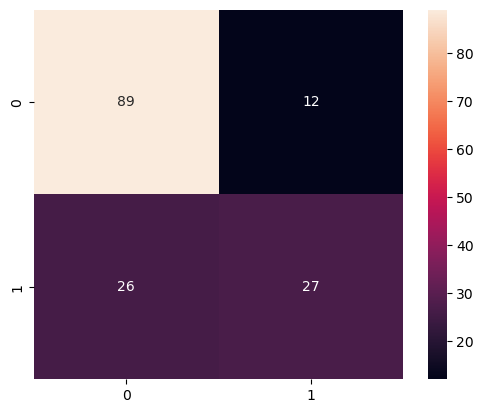

In [57]:
sns.heatmap(cm,annot=True,square=True)
plt.show()

In [58]:
print("Recall : ",recall)

Recall :  0.5094339622641509


In [59]:
y_prob_diabetes=y_prob[:,1]
y_prob_diabetes

array([0.42509034, 0.04333397, 0.70719418, 0.59085701, 0.04858115,
       0.10346472, 0.25170945, 0.01061505, 0.04016393, 0.13271971,
       0.045814  , 0.71786918, 0.14650721, 0.06657941, 0.40099272,
       0.3633202 , 0.09350525, 0.95160759, 0.64929862, 0.48857071,
       0.33966778, 0.03772316, 0.10912881, 0.01879946, 0.52789258,
       0.0420075 , 0.45104687, 0.27881264, 0.04551405, 0.15876087,
       0.67082396, 0.53002524, 0.04899732, 0.2452613 , 0.01812649,
       0.04685945, 0.57528066, 0.76246127, 0.5799073 , 0.01950947,
       0.24473241, 0.28545699, 0.11591882, 0.35927688, 0.31508578,
       0.12910843, 0.7116993 , 0.76347642, 0.03973707, 0.65953373,
       0.04131025, 0.07605543, 0.33330108, 0.716167  , 0.18161844,
       0.08336456, 0.55224104, 0.38461399, 0.29410706, 0.7313997 ,
       0.51408658, 0.12917866, 0.08334835, 0.29783735, 0.03668056,
       0.2967596 , 0.02933091, 0.06600569, 0.04894087, 0.92668373,
       0.37396478, 0.26557996, 0.81337175, 0.06451545, 0.19220

In [61]:
threshold=0.3
y_pred_custom=(y_prob_diabetes>=threshold).astype(int) # np.where(y_prob>=threshold,1,0)
y_pred_custom

array([1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1])

In [65]:
# After updating the threshold from 0.5 to 0.3
updated_recall=recall_score(y_test,y_pred_custom)
print("Recall Score after updating the Threshold : ",updated_recall)

Recall Score after updating the Threshold :  0.7547169811320755


In [67]:
print("Recall Score before updating the threshold : ",recall)

Recall Score before updating the threshold :  0.5094339622641509


In [69]:
print("Accuracy after updating the threshold:", accuracy_score(y_test, y_pred_custom))
print("Precision after updating the threshold:", precision_score(y_test, y_pred_custom))
print("Recall after updating the threshold:", recall_score(y_test, y_pred_custom))
print("F1 after updating the threshold:", f1_score(y_test, y_pred_custom))

Accuracy after updating the threshold: 0.7792207792207793
Precision after updating the threshold: 0.6557377049180327
Recall after updating the threshold: 0.7547169811320755
F1 after updating the threshold: 0.7017543859649122


In [70]:
print("Accuracy before updating the threshold:", accuracy_score(y_test, y_pred))
print("Precision before updating the threshold:", precision_score(y_test, y_pred))
print("Recall before updating the threshold:", recall_score(y_test, y_pred))
print("F1 before updating the threshold:", f1_score(y_test, y_pred))

Accuracy before updating the threshold: 0.7532467532467533
Precision before updating the threshold: 0.6923076923076923
Recall before updating the threshold: 0.5094339622641509
F1 before updating the threshold: 0.5869565217391305


In [72]:
print("Confusion Matrix before updating threshold : ",confusion_matrix(y_test,y_pred))

Confusion Matrix before updating threshold :  [[89 12]
 [26 27]]


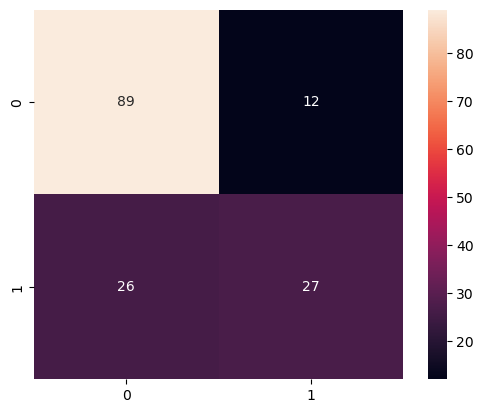

In [73]:
sns.heatmap(cm,annot=True,square=True)
plt.show()

In [81]:
cm_custom=confusion_matrix(y_test,y_pred_custom)
print("Confusion Matrix after updating threshold : ",cm_custom)

Confusion Matrix after updating threshold :  [[80 21]
 [13 40]]


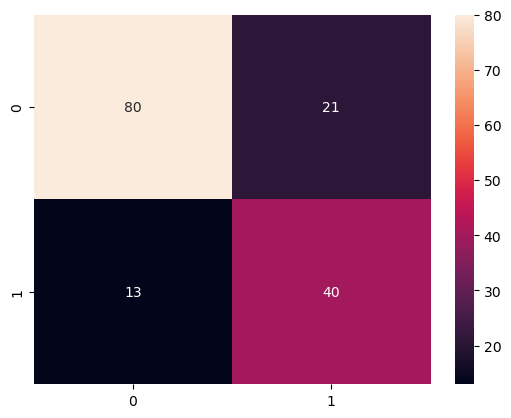

In [82]:
sns.heatmap(cm_custom,annot=True)
plt.show()

In [77]:
print("ROC_AUC score before updating the threshold : ",roc_auc_score(y_test,y_pred))

ROC_AUC score before updating the threshold :  0.6953110405380162


In [78]:
print("ROC_AUC score after updating the threshold : ",roc_auc_score(y_test,y_pred_custom))

ROC_AUC score after updating the threshold :  0.7733980945264338
